In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset original en crudo: la versión completa de `listings`, con 90 columnas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/raw/valencia/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,48154,https://www.airbnb.com/rooms/48154,20260626225654,2026-06-27,city scrape,Precioso apartamento con wifi,"Second floor in a late 19th century estate, ve...",NaN,https://a0.muscache.com/pictures/1109085/9c0d4...,219476,...,4.80,4.53,4.52,Valencia - Regional registration number<br />V...,NaN,4,4,0,0,1.17
1,137143,https://www.airbnb.com/rooms/137143,20260626225654,2026-07-03,previous scrape,PENTHOUSE ON FRONT LINE BEACH,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,670775,...,5.00,4.00,4.00,Valencia - Regional registration number<br />V...,NaN,5,5,0,0,0.01
2,149715,https://www.airbnb.com/rooms/149715,20260626225654,2026-06-27,city scrape,1900 Style Valencian Beach Home for 10px,Typical town house with 5 bedrooms and 4 bathr...,NaN,https://a0.muscache.com/pictures/808b4883-c57f...,5947,...,4.88,4.62,4.61,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,1.89
3,165971,https://www.airbnb.com/rooms/165971,20260626225654,2026-06-27,city scrape,★ Architectural touch! ★,"Hola! I am ready to welcome you in my apt., wh...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,791187,...,4.88,4.84,4.85,Valencia - Regional registration number<br />V...,NaN,12,12,0,0,3.37
4,182221,https://www.airbnb.com/rooms/182221,20260626225654,2026-06-27,city scrape,Apartments Calatrava City Valencia,NaN,NaN,https://a0.muscache.com/pictures/1161513/9f7ac...,1315567,...,4.70,4.40,4.50,Valencia - Regional registration number<br />V...,NaN,2,2,0,0,0.08


## 2. Básico

Primer vistazo a la estructura del dataset: dimensiones, tipos de datos y estadísticos descriptivos generales.

In [3]:
print(df.shape)
df.dtypes.value_counts()

(7851, 90)


float64    42
object     30
int64      18
Name: count, dtype: int64

90 columnas (7851 filas): 42 `float64`, 30 `object`, 18 `int64`: exactamente el mismo reparto de tipos que en Barcelona y Madrid, señal de que las tres ciudades vienen del mismo export de Inside Airbnb. Igual que en esos dos casos, `price` es `object` en vez de numérico (se ve en la sección 3), y hay columnas `float64` que por su nombre deberían ser texto o fecha (`host_since`, `host_response_time`...), lo que hace sospechar que están vacías.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].sort_index()

calendar_updated             100.0
host_acceptance_rate         100.0
host_neighbourhood           100.0
host_response_rate           100.0
host_response_time           100.0
host_since                   100.0
host_thumbnail_url           100.0
host_total_listings_count    100.0
host_verifications           100.0
instant_bookable             100.0
neighborhood_overview        100.0
neighbourhood                100.0
dtype: float64

**Las mismas 12 columnas que en Barcelona y Madrid están completamente vacías** (100% nulas): `neighbourhood`, `host_acceptance_rate`, `host_response_time`, `host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `host_since`, `host_response_rate`, `instant_bookable`, `neighborhood_overview`, `calendar_updated`. De las 90 columnas, solo 78 tienen algún dato real. No se eliminan aquí, se tratan formalmente en la sección 4 (Nulos).

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,7851.0,9.148930e+17,5.940743e+17,4.815400e+04,5.401484e+07,1.095651e+18,1.393116e+18,1.716042e+18
scrape_id,7851.0,2.026063e+13,3.906499e-03,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,7851.0,1.078082e+16,1.346720e+17,5.947000e+03,6.718475e+07,2.199552e+08,5.142261e+08,1.707801e+18
host_profile_id,7848.0,1.474370e+18,3.363972e+16,1.462507e+18,1.463470e+18,1.468336e+18,1.470300e+18,1.715087e+18
host_since,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,7848.0,6.535933e+00,4.000380e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.000000e+01,1.700000e+01
hosts_time_as_user_months,7848.0,5.429027e+00,3.631462e+00,0.000000e+00,2.000000e+00,5.000000e+00,9.000000e+00,1.100000e+01
hosts_time_as_host_years,7848.0,5.345948e+00,3.832110e+00,0.000000e+00,2.000000e+00,4.000000e+00,9.000000e+00,1.500000e+01
hosts_time_as_host_months,7848.0,5.077599e+00,3.605246e+00,0.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00,1.100000e+01


Igual que en las otras dos ciudades: `price` llega como texto (`"$150.64"`, no `150.64`), y aparece la misma familia `price_quote_*` (una cotización para unas fechas concretas de check-in/check-out, no el precio base del anuncio). Se tratan en la sección 3 y se retoman al analizar `price` a fondo en la sección 7-8.

## 3. Corrección de tipos

Ajustar columnas con un tipo de dato mal inferido. Mismos pasos que en Barcelona/Madrid, aplicados aquí a Valencia.

#### `price`

Llega como texto con símbolo de moneda y separador de miles. Se limpia y se convierte a `float`.

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].dtype

dtype('float64')

#### Fechas

`last_scraped`, `first_review`, `last_review` y `calendar_last_scraped` son fechas guardadas como texto. `host_since` se deja fuera: es una de las 12 columnas 100% vacías (se eliminará en la sección 4).

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df[date_cols].dtypes

last_scraped             datetime64[ns]
first_review             datetime64[ns]
last_review              datetime64[ns]
calendar_last_scraped    datetime64[ns]
dtype: object

#### Flags `t`/`f`

`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` y `has_availability` son booleanos codificados como texto (`"t"`/`"f"`), con algún nulo suelto. Se mapean a `boolean` (tipo nullable de pandas).

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}).astype("boolean"))
df[bool_cols].dtypes

host_is_superhost         boolean
host_has_profile_pic      boolean
host_identity_verified    boolean
has_availability          boolean
dtype: object

#### `host_profile_id`

Identificador entero con algunos nulos, pandas lo infirió como `float64`. Se pasa a `Int64` (entero nullable).

In [9]:
df["host_profile_id"] = df["host_profile_id"].astype("Int64")
df["host_profile_id"].dtype

Int64Dtype()

#### Distritos y barrios: normalizar mayúsculas

`neighbourhood_cleansed` y `neighbourhood_group_cleansed` llegan en MAYÚSCULAS SIN TILDES (p. ej. `"CIUTAT VELLA"`, `"L'EIXAMPLE"`), a diferencia de Barcelona/Madrid, donde el export ya trae los nombres bien formateados. Se normaliza a un formato más legible (capitalizando cada palabra, respetando apóstrofos y un pequeño grupo de partículas como "de"/"del"/"al") para que los desplegables de distrito/barrio de la app se vean igual de bien que en las otras dos ciudades. No se inventan tildes que el dato de origen no trae (p. ej. queda `"Ciutat Universitaria"`, no `"Ciutat Universitària"`): es una normalización de mayúsculas, no una corrección ortográfica.

In [10]:
import re

_SMALL_WORDS = {"de", "del", "la", "les", "els", "i", "en", "al", "dels"}

def title_case_place(name):
    tokens = re.split(r"([ -])", name)
    out = []
    seen_word = False
    for tok in tokens:
        if tok in (" ", "-"):
            out.append(tok)
            continue
        word = tok.lower()
        is_first = not seen_word
        seen_word = True
        if "'" in word:
            a, b = word.split("'", 1)
            a = a.capitalize() if is_first else a
            out.append(f"{a}'{b.capitalize()}")
        elif word in _SMALL_WORDS and not is_first:
            out.append(word)
        else:
            out.append(word.capitalize())
    return "".join(out)

for col in ["neighbourhood_cleansed", "neighbourhood_group_cleansed"]:
    df[col] = df[col].apply(title_case_place)

df[["neighbourhood_cleansed", "neighbourhood_group_cleansed"]].drop_duplicates().head(8)

,neighbourhood_cleansed,neighbourhood_group_cleansed
0,Morvedre,La Saidia
1,El Saler,Poblats del Sud
2,Cabanyal-Canyamelar,Poblats Maritims
3,La Roqueta,Extramurs
4,Aiora,Camins al Grau
7,La Creu del Grau,Camins al Grau
8,La Xerea,Ciutat Vella
10,Exposicio,El Pla del Real


Quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` y el resto de `price_quote_*`: su utilidad real se decide al analizar `price` a fondo, no aquí.

## 4. Nulos

Identificar qué columnas tienen valores nulos, en qué proporción, y decidir cómo tratarlos.

In [11]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

neighbourhood                  100.00
host_neighbourhood             100.00
host_thumbnail_url             100.00
host_verifications             100.00
host_acceptance_rate           100.00
host_response_rate             100.00
host_response_time             100.00
host_since                     100.00
host_total_listings_count      100.00
calendar_updated               100.00
instant_bookable               100.00
neighborhood_overview          100.00
host_about                      44.45
host_location                   26.34
license                         19.13
bedrooms                        18.84
bathrooms                       16.99
beds                            12.55
review_scores_location          11.86
review_scores_value             11.86
review_scores_communication     11.86
review_scores_checkin           11.86
review_scores_accuracy          11.86
review_scores_cleanliness       11.85
review_scores_rating            11.85
first_review                    11.85
last_review 

### 4.1 Estrategia

Mismo criterio que en Barcelona/Madrid, cada grupo de columnas según su causa:
- 12 columnas 100% vacías → se eliminan.
- `bathrooms` → se recupera desde `bathrooms_text`.
- Reviews (`reviews_per_month`, `first_review`/`last_review`, `review_scores_*`) → sin reviews todavía.
- `license` → sin licencia registrada.
- `price` → variable clave, no se imputa.
- Columnas de host/calendario de bajo volumen → se descartan las filas.
- `bedrooms`/`beds` → mediana por `room_type`.
- Campos de texto libre (`host_about`, `host_location`, `description`) → se dejan tal cual.

#### Columnas 100% vacías

In [12]:
empty_cols = [
    "neighbourhood", "host_acceptance_rate", "host_response_time", "host_thumbnail_url",
    "host_neighbourhood", "host_total_listings_count", "host_verifications", "host_since",
    "host_response_rate", "instant_bookable", "neighborhood_overview", "calendar_updated",
]
df = df.drop(columns=empty_cols)
df.shape

(7851, 78)

#### `bathrooms`

`bathrooms` (numérico) tiene 1334 nulos, pero `bathrooms_text` (texto, p. ej. `"1.5 baths"`) solo tiene 7. Se extrae el número de `bathrooms_text` (con `"half-bath"` → 0.5) y se usa para rellenar `bathrooms`.

In [13]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
half_mask = df["bathrooms_text"].str.contains("half-bath", case=False, na=False) & bathrooms_extracted.isnull()
bathrooms_extracted[half_mask] = 0.5

recovered = df["bathrooms"].isnull() & bathrooms_extracted.notnull()
print("bathrooms recuperados desde bathrooms_text:", recovered.sum())

df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
df["bathrooms"].isnull().sum()

bathrooms recuperados desde bathrooms_text: 1327


np.int64(7)

1327 de los 1334 nulos se recuperan (quedan 7, que coinciden con los 7 nulos de `bathrooms_text`).

#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_*`)

Se comprueba que el nulo coincide con `number_of_reviews == 0`.

In [14]:
mask = df["review_scores_rating"].isnull()
print("coincide con number_of_reviews == 0:", (df.loc[mask, "number_of_reviews"] == 0).all())
print("reviews_per_month coincide:", (df["reviews_per_month"].isnull() == mask).all())

coincide con number_of_reviews == 0: True
reviews_per_month coincide: True


Se confirma. `reviews_per_month` se imputa a 0. `first_review`/`last_review` se dejan como `NaT`, y `review_scores_*` como `NaN`: sin reviews no hay puntuación real que inventar.

In [15]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

El nulo probablemente significa que no hay licencia registrada. Se guarda como flag antes de imputar el texto.

In [16]:
df["has_license"] = df["license"].notna()
print(df["has_license"].value_counts(normalize=True).mul(100).round(2))
df["license"] = df["license"].fillna("Sin licencia")

has_license
True     80.87
False    19.13
Name: proportion, dtype: float64


80.9% de los anuncios tiene licencia registrada, más bajo que en Barcelona/Madrid, coherente con que la ordenanza de licencias turísticas de Valencia es más reciente.

#### `price`

Variable clave (7.44% nulo, 584 filas): no se imputa, se descartan esas filas.

In [17]:
df = df.dropna(subset=["price"])
df.shape

(7267, 79)

#### Columnas de bajo volumen (host, disponibilidad, estancia)

Afectan a muy pocas filas (0.18% del dataset), se descartan las filas en vez de imputar identificadores/metadatos de cuenta.

In [18]:
low_vol_cols = [
    "host_profile_id", "host_is_superhost", "host_name", "hosts_time_as_user_years",
    "host_identity_verified", "host_has_profile_pic", "hosts_time_as_user_months",
    "hosts_time_as_host_years", "host_listings_count", "hosts_time_as_host_months",
    "host_picture_url", "host_profile_url", "has_availability", "bathrooms_text",
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
]
df = df.dropna(subset=low_vol_cols)
df.shape

(7254, 79)

#### `bedrooms` / `beds`

Tras lo anterior quedan `bedrooms` con 18.18% de nulos y `beds` con 7.33%. Igual que en Barcelona, el nulo de `bedrooms` no es aleatorio: se concentra en `Private room` (57.4%) y `Shared room` (44.4%) frente a `Entire home/apt` (8.0%) y `Hotel room` (0%).

In [19]:
print(df.groupby("room_type")["bedrooms"].apply(lambda s: s.isnull().mean() * 100).round(1))
print()
print(df.groupby("room_type")["bedrooms"].median())

room_type
Entire home/apt     8.0
Hotel room          0.0
Private room       57.4
Shared room        44.4
Name: bedrooms, dtype: float64

room_type
Entire home/apt    2.0
Hotel room         1.0
Private room       1.0
Shared room        1.0
Name: bedrooms, dtype: float64


Se imputa con la **mediana de `bedrooms`/`beds` dentro de cada `room_type`** (2 para `Entire home/apt`, 1 para el resto), la misma regla que en Barcelona/Madrid.

In [20]:
df["bedrooms"] = df.groupby("room_type")["bedrooms"].transform(lambda s: s.fillna(s.median()))
df["beds"] = df.groupby("room_type")["beds"].transform(lambda s: s.fillna(s.median()))

df[["bedrooms", "beds"]].isnull().sum()

bedrooms    0
beds        0
dtype: int64

In [21]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_about                     44.21
host_location                  26.59
review_scores_value            11.18
review_scores_accuracy         11.18
review_scores_checkin          11.18
review_scores_communication    11.18
review_scores_location         11.18
review_scores_cleanliness      11.17
review_scores_rating           11.17
first_review                   11.17
last_review                    11.17
description                     2.00
dtype: float64

Quedan sin tratar, a propósito: `review_scores_*`/`first_review`/`last_review` (informativamente vacíos) y los campos de texto libre `host_about`, `host_location`, `description`.

## 5. Duplicados

Comprobar si existen filas duplicadas en el dataset y eliminarlas si procede.

In [22]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que la fila completa.

In [23]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

Filas que comparten `name`, `host_name`, `latitude` y `longitude` pero tienen `id` distinto.

In [24]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
logical_dup_mask = df.duplicated(subset=dup_cols, keep=False)

print("filas implicadas:", logical_dup_mask.sum())
print("grupos:", df[logical_dup_mask].groupby(dup_cols).ngroups)

filas implicadas: 111
grupos: 37


111 filas repartidas en 37 grupos: en su mayoría son residencias/aparthoteles que publican la misma unidad tipo varias veces (p. ej. "Estudio individual con cocina" de una residencia de estudiantes, con 9 anuncios casi idénticos salvo `id`). Se comprueba si alguno coincide también en el resto de columnas.

In [25]:
cols_except_id = [c for c in df.columns if c != "id"]
is_real_duplicate = df.duplicated(subset=cols_except_id, keep="first")
is_real_duplicate.sum()

np.int64(0)

#### Conclusión

0 filas duplicadas de fila completa, 0 `id` repetidos, y 0 filas idénticas en todo salvo `id`: **no hay ningún duplicado que eliminar**. Los 111 "duplicados lógicos" son anuncios reales distintos (unidades diferentes del mismo edificio/residencia), con datos propios en el resto de columnas. No se toca nada.

## 6. Variables Categóricas

Análisis univariante de las variables categóricas: cardinalidad y distribución de frecuencias.

In [26]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

listing_url                     7254
picture_url                     7162
name                            6942
price_quote_raw                 6864
amenities                       6585
description                     6011
license                         5111
host_profile_url                2950
host_url                        2950
host_picture_url                2872
host_name                       1615
host_about                      1289
price_quote_checkout_date        298
price_quote_checkin_date         252
host_location                    228
neighbourhood_cleansed            84
property_type                     41
bathrooms_text                    27
neighbourhood_group_cleansed      19
room_type                          4
has_availability                   2
host_identity_verified             2
source                             2
host_has_profile_pic               2
host_is_superhost                  2
has_license                        2
dtype: int64

### 6.1 Cardinalidad: los mismos cuatro grupos que en Barcelona/Madrid

- **URLs**, cardinalidad prácticamente igual al nº de filas (`listing_url`, `picture_url`, `host_url`...): sin valor analítico.
- **Cuasi-identificadores de texto libre** (`name`, `description`, `host_about`, `amenities`, `host_name`, `host_location`, `license`): se difiere a feature engineering.
- **Pendientes de la sección 7-8** (`price_quote_checkin_date`, `price_quote_checkout_date`, `price_quote_raw`).
- **`bathrooms_text`**: ya cumplió su función en la sección 4.
- **Categóricas reales de baja cardinalidad**: `source` (2), `property_type` (41), `room_type` (4), `neighbourhood_cleansed` (84), `neighbourhood_group_cleansed` (19), `has_availability` (2), y los booleanos `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `has_license`.

Una diferencia con Barcelona/Madrid: Valencia tiene **19 distritos** (`neighbourhood_group_cleansed`) y **84 barrios**, más granular que las otras dos ciudades.

### 6.2 Categóricas de baja cardinalidad

#### `has_availability`

In [27]:
df["has_availability"].value_counts(dropna=False)

has_availability
True     7250
False       4
Name: count, dtype: Int64

7250 `True` frente a solo 4 `False`: a diferencia de Barcelona (donde quedó perfectamente constante), aquí sobreviven 4 filas con `False`, pero es prácticamente una constante (99.94%). Con tan poca variación no va a distinguir nada como predictora, así que se elimina igual que en Barcelona/Madrid.

In [28]:
df = df.drop(columns=["has_availability"])

#### `source`

In [29]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        95.1
previous scrape     4.9
Name: proportion, dtype: float64

95.1% `city scrape` / 4.9% `previous scrape`, muy similar a Barcelona. Metadato de recolección, se deja como está.

#### `property_type`

In [30]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   4692
Private room in rental unit          1012
Entire loft                           440
Entire home                           191
Entire condo                          158
Entire serviced apartment             128
Private room in home                  110
Room in hotel                          94
Private room in condo                  64
Private room in bed and breakfast      60
Private room in hostel                 56
Room in aparthotel                     55
Entire townhouse                       32
Private room in casa particular        30
Room in boutique hotel                 29
Name: count, dtype: int64

Dominado por `Entire rental unit` (64.7%) y `Private room in rental unit` (14.0%). Con 41 categorías en total, si se usa como feature habrá que agrupar las de cola larga, igual que en las otras ciudades.

#### `room_type`

In [31]:
df["room_type"].value_counts()

room_type
Entire home/apt    5743
Private room       1487
Shared room          18
Hotel room            6
Name: count, dtype: int64

`Entire home/apt` domina (79.2%), `Shared room`/`Hotel room` son casi residuales (18 y 6 filas).

#### `neighbourhood_group_cleansed` / `neighbourhood_cleansed`

In [32]:
df["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Poblats Maritims     1372
Ciutat Vella         1240
Quatre Carreres       725
Camins al Grau        655
Extramurs             609
L'Eixample            609
Algiros               314
La Saidia             308
Jesus                 225
L'Olivereta           210
Patraix               169
Rascanya              157
Poblats del Sud       138
El Pla del Real       135
Campanar              125
Benicalap             124
Benimaclet             79
Poblats de l'Oest      55
Poblats del Nord        5
Name: count, dtype: int64

`Poblats Marítims` (el litoral, incluye el Cabanyal y la Malvarrosa) y `Ciutat Vella` (centro histórico) concentran la mayoría de anuncios, un patrón parecido al de Barcelona (litoral + centro histórico como polos turísticos), pero repartido entre 19 distritos en vez de 10. No se repite aquí el análisis detallado de barrios raros. Se retomará si hace falta en feature engineering.

#### Columnas booleanas

In [33]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c)
    print(df[c].value_counts(normalize=True).mul(100).round(1))
    print()

host_is_superhost
host_is_superhost
False    66.6
True     33.4
Name: proportion, dtype: Float64

host_has_profile_pic
host_has_profile_pic
True     97.0
False     3.0
Name: proportion, dtype: Float64

host_identity_verified
host_identity_verified
True     98.2
False     1.8
Name: proportion, dtype: Float64

has_license
has_license
True     82.5
False    17.5
Name: proportion, dtype: float64



`host_has_profile_pic` (97.0%) y `host_identity_verified` (98.2%) casi siempre a `True`, poca variabilidad. `host_is_superhost` (33.4% `True`) más equilibrado. `has_license` a `True` en el 82.5% de los casos, algo por debajo de lo habitual en Barcelona/Madrid.

## 7. Numéricas

Análisis univariante de las variables numéricas: estadísticos descriptivos y forma de la distribución.

In [34]:
num_cols = df.select_dtypes(include="number").columns
print(num_cols.tolist())
len(num_cols)

['id', 'scrape_id', 'host_id', 'host_profile_id', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_listings_count', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_h

49

### 7.1 Identificadores/geográficas vs. variables de interés

49 columnas numéricas, igual que en Barcelona/Madrid (mismo esquema de columnas). `id`, `scrape_id`, `host_id`, `host_profile_id` son identificadores. `latitude`/`longitude` se tratan en la sección 11. El resto tiene las mismas familias redundantes ya vistas en las otras ciudades, se revisan antes de elegir cuáles analizar a fondo.

### 7.2 Familias de variables redundantes

In [35]:
nights_family = [
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
]
df[nights_family].corr().round(2)

,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm
minimum_nights,1.00,-0.01,1.00,0.74,0.05,-0.01,0.92,0.03
maximum_nights,-0.01,1.00,-0.01,-0.00,0.74,1.00,-0.01,0.87
minimum_minimum_nights,1.00,-0.01,1.00,0.74,0.05,-0.01,0.92,0.03
maximum_minimum_nights,0.74,-0.00,0.74,1.00,0.03,-0.00,0.87,0.01
minimum_maximum_nights,0.05,0.74,0.05,0.03,1.00,0.74,0.04,0.93
maximum_maximum_nights,-0.01,1.00,-0.01,-0.00,0.74,1.00,-0.01,0.87
minimum_nights_avg_ntm,0.92,-0.01,0.92,0.87,0.04,-0.01,1.00,0.02
maximum_nights_avg_ntm,0.03,0.87,0.03,0.01,0.93,0.87,0.02,1.00


`minimum_nights` y `minimum_minimum_nights` correlacionan **1.00**, literalmente el mismo dato, igual que en Barcelona. Para el EDA basta con `minimum_nights`/`maximum_nights`.

In [36]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365", "availability_eoy"]
df[avail_family].corr().round(2)

,availability_30,availability_60,availability_90,availability_365,availability_eoy
availability_30,1.00,0.89,0.79,0.27,0.49
availability_60,0.89,1.00,0.92,0.32,0.59
availability_90,0.79,0.92,1.00,0.41,0.73
availability_365,0.27,0.32,0.41,1.00,0.75
availability_eoy,0.49,0.59,0.73,0.75,1.00


Solape moderado (0.27 a 0.92). Se sigue usando `availability_365`, la más completa.

### 7.3 Comprobación: `hosts_time_as_*` y `host_listings_count`

In [37]:
hosts_time_cols = ["hosts_time_as_user_years", "hosts_time_as_user_months", "hosts_time_as_host_years", "hosts_time_as_host_months"]
df[hosts_time_cols].describe()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months
count,7254.000000,7254.000000,7254.000000,7254.000000
mean,6.515715,5.440585,5.341880,5.111249
std,4.016815,3.628705,3.845495,3.611058
min,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,2.000000,2.000000
50%,7.000000,5.000000,4.000000,4.000000
75%,10.000000,9.000000,9.000000,8.000000
max,17.000000,11.000000,15.000000,11.000000


Sin nulos, rangos razonables: son campos derivados que sobrevivieron aunque `host_since` esté vacía, igual que en Barcelona.

In [38]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.388097
calculated_host_listings_count,0.388097,1.000000


**Diferencia notable con Barcelona/Madrid**: aquí la correlación entre `host_listings_count` (autodeclarado) y `calculated_host_listings_count` (recalculado dentro del dataset) es solo **0.39**, muy por debajo del ~0.9 de las otras ciudades. Los hosts valencianos autodeclaran una cartera de anuncios que se relaciona bastante menos con lo que realmente aparece en el dataset de Valencia, probablemente porque muchos gestionan también anuncios en otras ciudades/plataformas. Para el análisis de Valencia se sigue usando `calculated_host_listings_count`, por ser específico de este dataset.

### 7.4 Variables clave: estadísticos y asimetría

In [39]:
num_vars = [
    "price", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "calculated_host_listings_count", "estimated_revenue_l365d",
]
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
price,7254.0,177.197734,251.744682,1.87,103.8125,150.64,200.00,9900.00
accommodates,7254.0,3.600221,1.837784,1.00,2.0000,4.00,4.00,16.00
bathrooms,7254.0,1.253446,0.575571,0.00,1.0000,1.00,1.50,14.00
bedrooms,7254.0,1.653846,0.904803,1.00,1.0000,1.00,2.00,14.00
beds,7254.0,2.218638,1.411224,1.00,1.0000,2.00,3.00,25.00
minimum_nights,7254.0,6.004549,15.973648,1.00,1.0000,2.00,10.00,365.00
maximum_nights,7254.0,574.638269,455.563066,1.00,100.0000,365.00,1125.00,1125.00
availability_365,7254.0,192.932313,106.654534,1.00,98.0000,193.00,294.00,365.00
number_of_reviews,7254.0,59.584092,95.538163,0.00,4.0000,21.00,72.00,989.00
number_of_reviews_ltm,7254.0,15.228150,19.133553,0.00,1.0000,7.00,24.00,124.00


In [40]:
df[num_vars].skew().sort_values(ascending=False)

price                             20.140109
minimum_nights                    16.270753
estimated_revenue_l365d            8.727174
bathrooms                          3.830006
beds                               3.123631
number_of_reviews                  2.916784
calculated_host_listings_count     2.255323
bedrooms                           1.927375
reviews_per_month                  1.826383
number_of_reviews_ltm              1.691636
accommodates                       1.337061
maximum_nights                     0.167131
availability_365                  -0.079037
review_scores_rating              -3.849975
dtype: float64

`price` tiene una asimetría enorme (**20.1**, muy por encima de Barcelona), y `minimum_nights` también (16.3). `review_scores_rating` repite la asimetría negativa fuerte (-3.85) ya vista en las otras ciudades: la mayoría puntúa muy alto. La asimetría de `price` es sospechosa incluso para una variable de precio (que siempre tiene cola larga): se investiga a fondo en la sección 8, donde aparece una causa muy concreta.

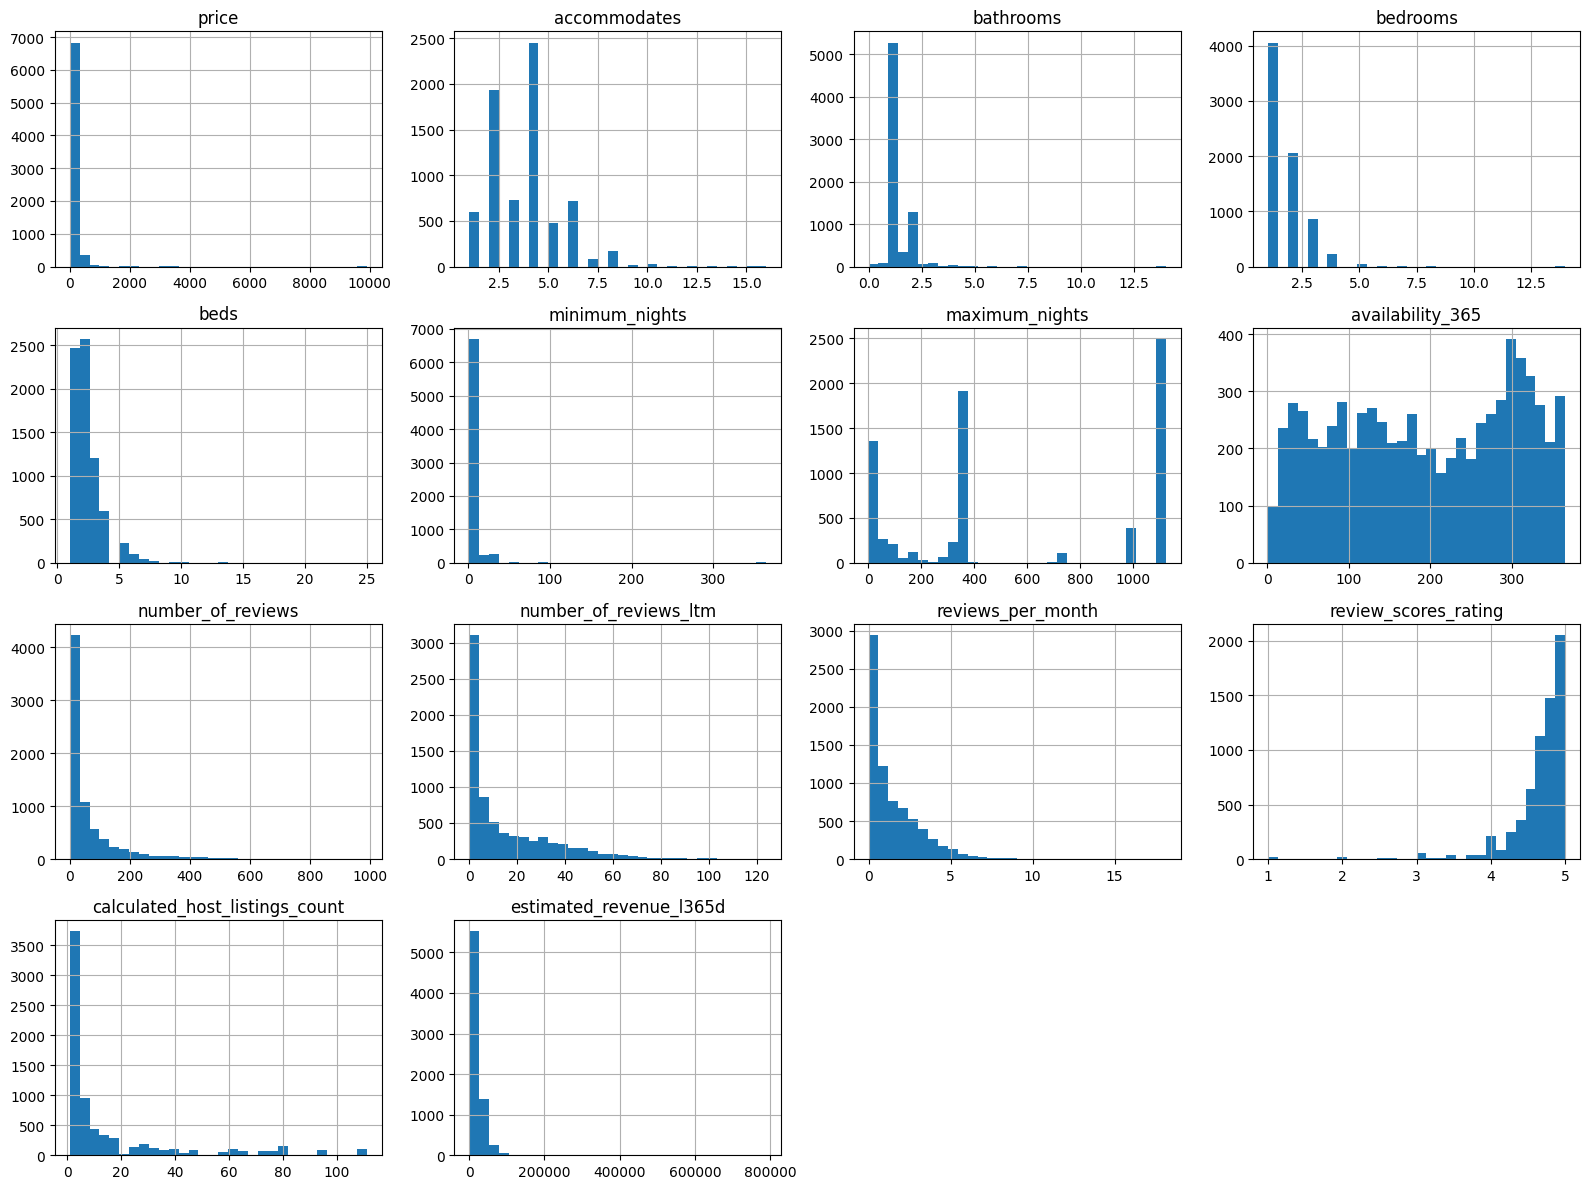

In [41]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()

## 8. Outliers

Detección y tratamiento de valores extremos que puedan distorsionar el análisis.

### 8.1 Método: rango intercuartílico (IQR)

In [42]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c, "low": low, "high": high,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
12,calculated_host_listings_count,-20.00000,36.00000,957,13.19
8,number_of_reviews,-98.00000,174.00000,711,9.80
11,review_scores_rating,4.05000,5.41000,449,6.19
0,price,-40.46875,344.28125,387,5.33
5,minimum_nights,-12.50000,23.50000,335,4.62
9,number_of_reviews_ltm,-33.50000,58.50000,289,3.98
3,bedrooms,-0.50000,3.50000,282,3.89
2,bathrooms,0.25000,2.25000,270,3.72
1,accommodates,-1.00000,7.00000,260,3.58
13,estimated_revenue_l365d,-34170.62500,61128.37500,217,2.99


`calculated_host_listings_count` (13.2%) y `number_of_reviews` (9.8%) encabezan la lista, igual que en Barcelona. `price` sale con 5.3%: hay que mirar de cerca cuáles son esos extremos, porque la asimetría de la sección 7 (20.1) es demasiado alta incluso para eso.

### 8.2 Caso concreto: precios de 9900 € y 3000 € (artefactos de captura, no mercado real)

In [43]:
df.sort_values("price", ascending=False)[["name", "host_name", "room_type", "accommodates", "price"]].head(10)

,name,host_name,room_type,accommodates,price
4455,Apartamento cerca del AVE,Jose,Entire home/apt,2,9900.00
647,SOROLLA 1 BEDROOM,Jose,Entire home/apt,2,9593.10
6308,𓇼Cozy l Centro l Trasporte publico,Olivera,Entire home/apt,4,3557.00
6931,𓇼 Terraza | Céntrico | Transp. público | Diseño,Ruben,Entire home/apt,4,3511.00
4875,Quiet Loft,Jose Luis,Entire home/apt,5,3444.67
5465,Bungalow Cahaya,Camping Valencia,Entire home/apt,4,3000.00
5476,Bungalow Nisarga,Camping Valencia,Entire home/apt,4,3000.00
5475,Bungalow Nisarga,Camping Valencia,Entire home/apt,4,3000.00
5474,Bungalow Nisarga,Camping Valencia,Entire home/apt,4,3000.00
5473,Bungalow Nisarga,Camping Valencia,Entire home/apt,4,3000.00


Dos casos llaman la atención:
- **"Apartamento cerca del AVE"**: un piso para 2 personas a **9900 €/noche**. Es la única fila con ese precio.
- **19 "Bungalow ..." del mismo host, "Camping Valencia"**: todos a exactamente **3000 €/noche**, un precio idéntico repetido en 19 anuncios distintos del mismo camping.

Ni el tamaño ni la ubicación justifican esos precios (la mediana general es ~150€). Se comprueba `price_quote_raw`, que trae el detalle de la cotización consultada en el scraping.

In [44]:
import json

row = df.loc[df["price"] == 9900.0].iloc[0]
quote = json.loads(row["price_quote_raw"])["quote"]
print("fecha consultada:", quote["requested_checkin_date"], "->", quote["requested_checkout_date"])
print("price_per_night:", quote["price_per_night"])

fecha consultada: 2027-04-30 -> 2027-05-11
price_per_night: 9900


El precio es internamente consistente (`price_per_night` coincide con `price`), no es un error de parseo. Es un patrón conocido en Airbnb: algunos hosts, en vez de bloquear el calendario para una fecha, le ponen un precio absurdamente alto para que quede técnicamente "disponible" pero de facto "no reservable". Los 19 bungalows de "Camping Valencia" a 3000€ apuntan a lo mismo, aplicado de forma sistemática a todo el inventario de un solo host. No son 20 observaciones independientes del mercado, son la misma anomalía de captura repetida. Se descartan (20 filas, 0.28% del dataset): igual que con los nulos de `price` en la sección 4, esta es la variable clave, no se "corrige" inventando un valor, se elimina la fila.

In [45]:
price_artifact_mask = df["price"].isin([9900.0, 3000.0])
print("filas descartadas:", price_artifact_mask.sum())
df = df[~price_artifact_mask]
df.shape

filas descartadas: 20


(7234, 78)

### 8.3 Caso concreto: `bedrooms`/`beds`/`bathrooms` de un anuncio individual

Además del precio, conviene revisar el tamaño: hay anuncios `Private room` con `bedrooms`/`bathrooms` altos que a primera vista parecen raros, pero suelen ser habitaciones dentro de coliving o casas compartidas grandes (el conteo es real, de todo el piso). Se aísla el caso donde las tres variables de tamaño coinciden en un valor idéntico y anormalmente alto a la vez, la huella típica de un error de captura (estadísticas de todo el edificio copiadas en una sola fila).

In [46]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "bathrooms", "price"]
error_mask = (df["bedrooms"] > 10) & (df["beds"] > 10) & (df["bathrooms"] > 10)
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price
7371,A2B Collection Arena View,Private room,4,14.0,14.0,14.0,167.0


"A2B Collection Arena View": `Private room` para 4 personas con `bedrooms=beds=bathrooms=14`. Los tres valores idénticos y muy por encima de lo que cabe en una habitación privada para 4 personas confirman el error (parecen las cifras del hotel completo, no de la habitación reservable). Se corrige igual que un nulo: se reimputa con la misma regla ya usada en la sección 4 (mediana por `room_type`).

In [47]:
for c in ["bedrooms", "beds", "bathrooms"]:
    df.loc[error_mask, c] = df.groupby("room_type")[c].transform("median")[error_mask]
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price
7371,A2B Collection Arena View,Private room,4,1.0,1.0,1.0,167.0


### 8.4 Visualización

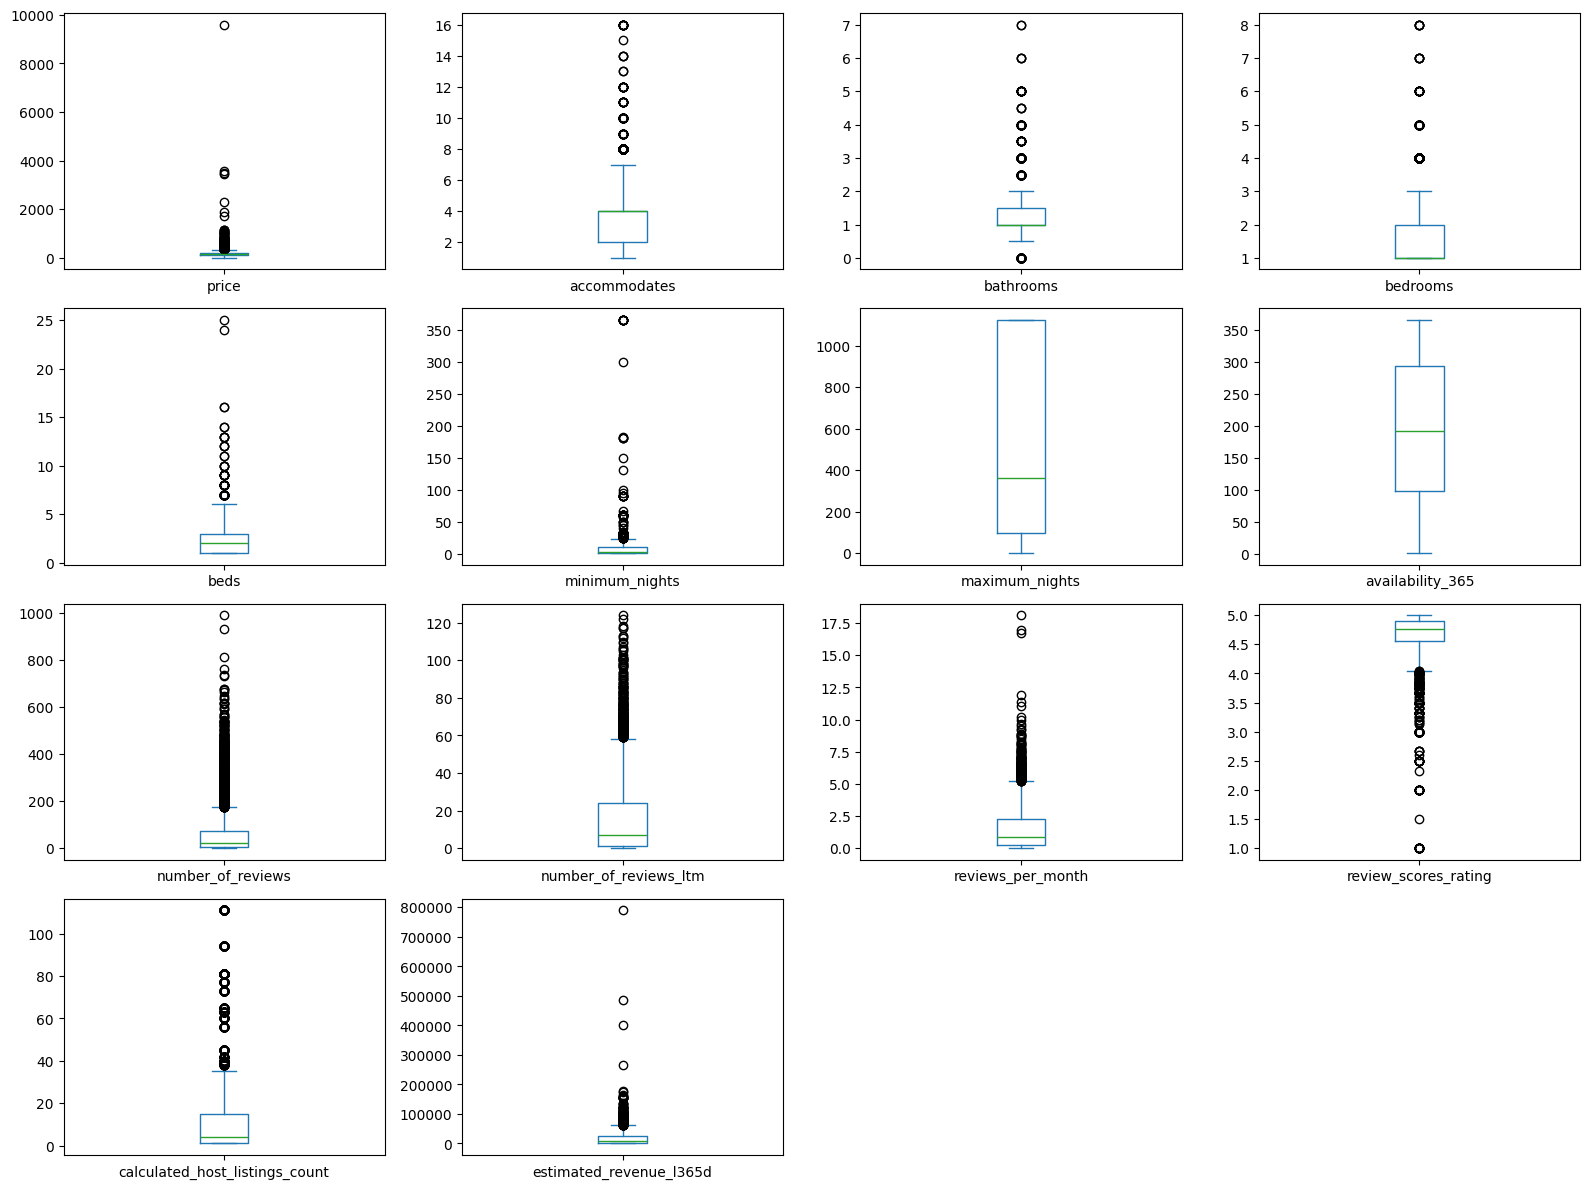

In [48]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 12))
plt.tight_layout()

### 8.5 El precio de limpiar bien: la correlación con `price` mejora

Antes de seguir, se comprueba el efecto de haber quitado los 20 precios-artefacto: se compara la correlación de las variables de tamaño con `price` antes y después.

In [49]:
size_vars = ["accommodates", "bedrooms", "bathrooms", "beds"]
for c in size_vars:
    print(f"{c}: pearson={df['price'].corr(df[c]):.2f}  spearman={df['price'].corr(df[c], method='spearman'):.2f}")

accommodates: pearson=0.35  spearman=0.63
bedrooms: pearson=0.24  spearman=0.39
bathrooms: pearson=0.16  spearman=0.21
beds: pearson=0.30  spearman=0.51


`accommodates` pasa de 0.23 a **0.35** de Pearson, `beds` de 0.20 a **0.30**, `bedrooms` de 0.16 a **0.24**, solo por quitar 20 filas (0.28% del dataset). Confirma que esos precios no eran variabilidad real: eran ruido puro que diluía la señal real de tamaño → precio. Spearman apenas cambia (0.62, 0.51, 0.39), porque al ser un estadístico de rangos ya era más robusto a esos extremos.

### 8.6 Conclusión y tratamiento

Con las dos correcciones ya aplicadas (20 filas de precio-artefacto descartadas, 1 fila de tamaño-artefacto reimputada), **no se recorta nada más por IQR**: el resto de "outliers" (`calculated_host_listings_count`, `number_of_reviews`, la cola alta de `price` que queda, las notas bajas de `review_scores_rating`) son variabilidad real del mercado, no errores. Las transformaciones para modelar (logs, etc.) se dejan para feature engineering.

## 9. Agrupaciones

Análisis bivariante: relación de `price` con otras variables categóricas.

#### `neighbourhood_group_cleansed` / `room_type` (repaso rápido)

In [50]:
print(df.groupby("neighbourhood_group_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False))
print()
print(df.groupby("room_type")["price"].agg(["count", "mean", "median"]))

                              count        mean   median
neighbourhood_group_cleansed                            
Poblats del Nord                  5  230.146000  220.670
Ciutat Vella                   1240  194.324532  165.000
L'Eixample                      609  191.500640  164.000
Poblats Maritims               1372  181.778630  163.955
Benicalap                       124  179.544919  130.385
Camins al Grau                  655  173.903893  153.000
Extramurs                       609  163.971708  154.090
El Pla del Real                 135  160.590148  139.550
La Saidia                       308  156.655162  142.000
Quatre Carreres                 725  154.953490  146.250
Poblats del Sud                 119  147.282269  136.950
Patraix                         169  144.552485  133.910
Benimaclet                       79  141.113418  152.640
L'Olivereta                     210  139.544905  125.875
Campanar                        125  135.519120  120.720
Jesus                          

`Ciutat Vella` y `L'Eixample` (el ensanche valenciano) encabezan por media. `Poblats del Nord` sale primero pero con solo 5 anuncios, poco fiable. `Entire home/apt` (mediana 165€) muy por encima de `Private room` (60.5€) y `Shared room` (31€), igual que en Barcelona.

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

In [51]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
1.0,4049,130.00
2.0,2035,169.50
3.0,869,197.68
4.0,219,218.62
5.0,39,257.00
6.0,13,485.00
7.0,5,204.27
8.0,5,29.87


Relación creciente y bastante monótona: 1 dormitorio → mediana 130€, 2 → 170€, 3 → 198€, 4 → 219€, 5 → 257€, hasta 6 dormitorios → 485€. La caída en 7-8 dormitorios es ruido de muestra muy pequeña (5 filas cada una).

<Axes: xlabel='bedrooms', ylabel='price'>

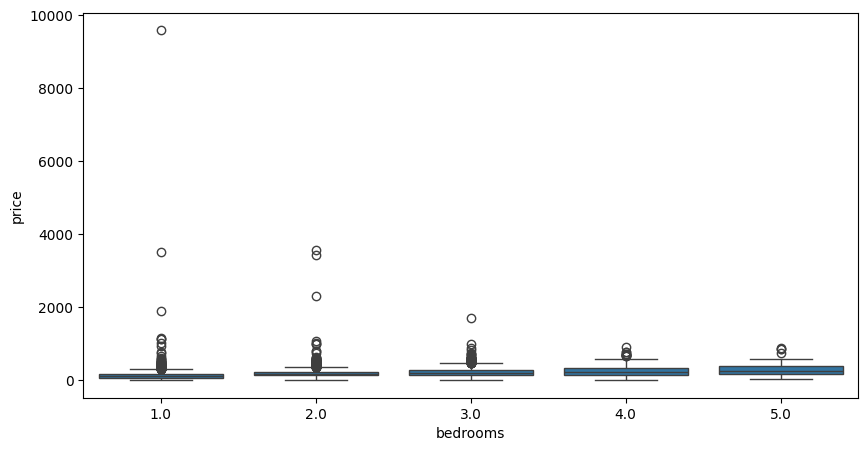

In [52]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 5], x="bedrooms", y="price")

Se limita a ≤5 dormitorios (en Valencia la muestra de 6+ es demasiado pequeña para que la caja tenga sentido). La tendencia creciente se ve con claridad.

### 9.2 Calidad: `review_scores_rating`

In [53]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(0.02950345437169726), np.float64(0.04662772804054498))

Prácticamente cero (Pearson 0.03, Spearman 0.05), igual que en Barcelona: casi todo el mundo puntúa alto, la nota apenas distingue precio.

### 9.3 `has_license`

In [54]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,1253,115.417342,80.00
True,5981,179.547639,158.45


Diferencia grande: mediana 158€ con licencia vs. 80€ sin ella, prácticamente el doble. Se comprueba si es solo un efecto de `room_type`.

In [55]:
df.groupby(["room_type", "has_license"])["price"].median()

room_type        has_license
Entire home/apt  False          155.00
                 True           165.50
Hotel room       False           56.50
                 True           129.00
Private room     False           58.00
                 True            64.53
Shared room      False          102.71
                 True            29.00
Name: price, dtype: float64

Se mantiene dentro de `Entire home/apt` (165.5€ con licencia vs. 155€ sin ella, diferencia más moderada que en el agregado) y sobre todo en `Private room` (64.5€ vs 58€), así que no es puramente un efecto de `room_type`, aunque el salto es menos dramático que el agregado sugería. Curiosamente en `Shared room` se invierte (29€ con licencia vs 102.71€ sin ella), pero la muestra ahí es mínima (18 filas en total).

### 9.4 `host_is_superhost`

In [56]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,4813,165.669578,148.0
True,2421,173.946584,155.2


Diferencia pequeña (mediana 155.2€ vs 148€): ser Superhost pesa poco en el precio, igual que en Barcelona.

### 9.5 `property_type` (más granular que `room_type`)

In [57]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
property_type,,,
Entire serviced apartment,128,227.953438,204.815
Entire home,172,270.677093,201.015
Entire rental unit,4691,191.465236,165.500
Entire condo,158,171.930886,159.750
Entire loft,440,160.186250,146.500
Room in hotel,94,138.276702,124.150
Private room in bed and breakfast,60,82.674833,74.375
Private room in condo,64,76.207656,63.400
Private room in rental unit,1012,70.661067,55.550


`Entire serviced apartment` (mediana 205€) y `Entire home` (201€) son los tipos más caros, por delante de `Entire rental unit` (166€). `Private room in home` es el más barato (54€).

En conjunto, esta sección apunta en la misma dirección que Barcelona: **tamaño y `has_license` son las señales de precio más consistentes**, `review_scores_rating` casi no aporta. Se retoma de forma cuantitativa en la sección 10.

## 10. Correlación y visualización

Análisis multivariante: correlaciones entre variables numéricas y su relación conjunta con `price`.

### 10.1 Correlación con `price`

In [58]:
corr_vars = num_vars + ["has_license", "host_is_superhost"]
df[corr_vars].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
estimated_revenue_l365d           0.389374
accommodates                      0.351294
beds                              0.298421
bedrooms                          0.235529
bathrooms                         0.164847
has_license                       0.141373
calculated_host_listings_count    0.077633
maximum_nights                    0.045623
review_scores_rating              0.029503
host_is_superhost                 0.022752
number_of_reviews                 0.020942
availability_365                  0.020239
number_of_reviews_ltm             0.011735
reviews_per_month                 0.008685
minimum_nights                   -0.119972
Name: price, dtype: float64

`estimated_revenue_l365d` (0.39) y `accommodates` (0.35) encabezan, seguidos de `beds` (0.30) y `bedrooms` (0.24). Con Pearson, las correlaciones son bastante más bajas que en Barcelona (donde `bedrooms` llegaba a 0.66): la cola larga de `price` sigue pesando incluso tras quitar los 20 artefactos de la sección 8.

In [59]:
df[corr_vars].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.626200
beds                              0.508602
bedrooms                          0.389949
estimated_revenue_l365d           0.309038
has_license                       0.307959
bathrooms                         0.213726
number_of_reviews                 0.113569
number_of_reviews_ltm             0.105672
reviews_per_month                 0.092119
calculated_host_listings_count    0.079355
maximum_nights                    0.071448
host_is_superhost                 0.055471
review_scores_rating              0.046628
availability_365                 -0.007759
minimum_nights                   -0.315076
Name: price, dtype: float64

Con Spearman el panorama cambia bastante y se parece mucho más a Barcelona: `accommodates` sube a **0.63**, `beds` a 0.51, `bedrooms` a 0.39: señal mucho más fuerte y robusta a la asimetría que la de Pearson. `has_license` también sube con fuerza (0.31). Como `price` sigue teniendo una cola larga real (aunque ya sin los artefactos), Spearman es el método de referencia para juzgar la importancia relativa de las variables en Valencia.

### 10.2 Heatmap

<Axes: >

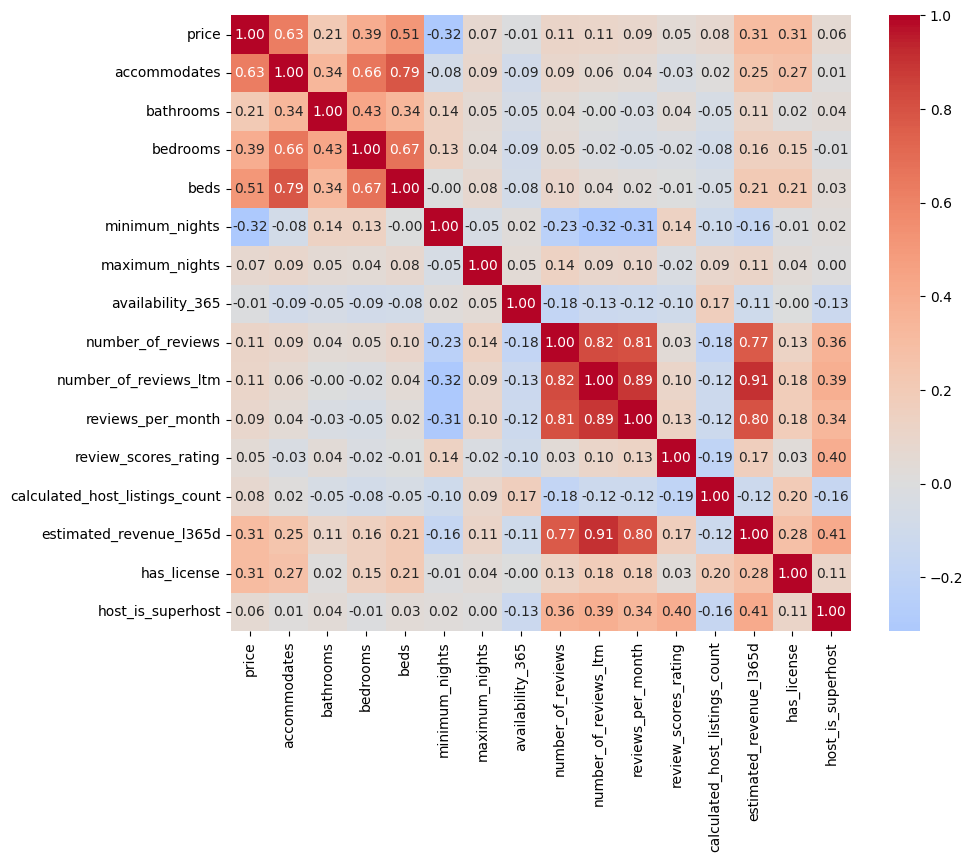

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_vars].corr(method="spearman"),
    annot=True, fmt=".2f", center=0, cmap="coolwarm",
)

`accommodates`/`bedrooms`/`beds`/`bathrooms` están muy correlacionadas entre sí (miden aspectos del mismo "tamaño"), igual que en Barcelona: habrá que vigilar la multicolinealidad de cara a un modelo lineal.

### 10.3 Pairplot

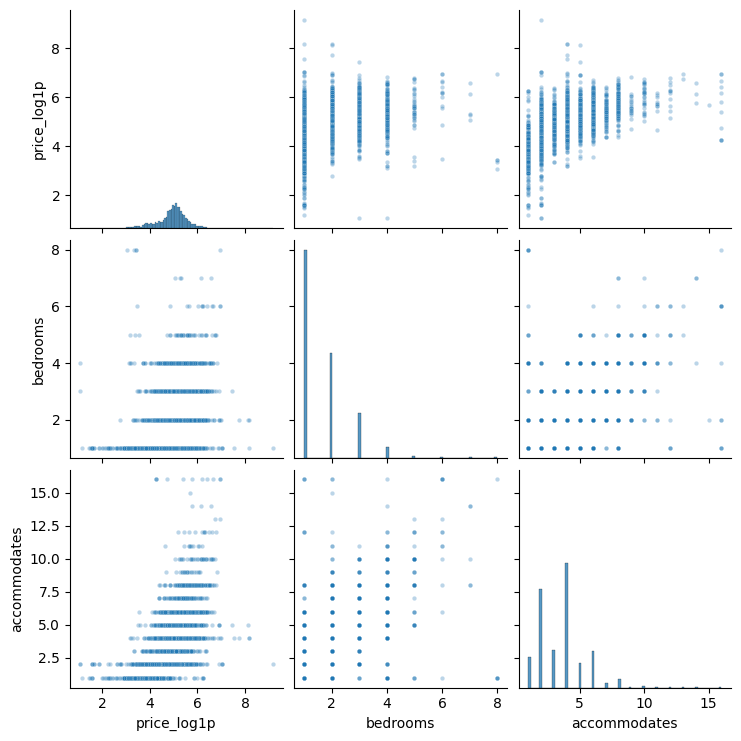

In [61]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price"] = np.log1p(pairplot_data["price"])
pairplot_data = pairplot_data.rename(columns={"price": "price_log1p"})

sns.pairplot(pairplot_data, plot_kws={"alpha": 0.3, "s": 10})

Se ve la relación creciente entre `price_log1p` y ambas variables, y la línea vertical en `accommodates=16` (el máximo permitido en Airbnb), igual que en Barcelona. Ya sin los 20 precios-artefacto de la sección 8, no queda ningún grupo aislado extraño en la esquina superior.

La sección 10 deja claro el orden de importancia para un futuro modelo de `price` en Valencia: primero el **tamaño** (`accommodates`/`beds`/`bedrooms`/`bathrooms`, mejor visto con Spearman que con Pearson), después `has_license`, y al final señales que apenas aportan por sí solas como `review_scores_rating` o `host_is_superhost`.

## 11. Análisis geográfico

Visualización espacial de los anuncios (latitud/longitud) para detectar patrones de precio o densidad por zona.

### 11.1 Rango de coordenadas

In [62]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,39.280030,-0.426401
max,39.542854,-0.276280


Rango coherente con Valencia (lat ~39.28-39.54, long ~-0.43 a -0.28): sin sorpresas.

### 11.2 Distribución espacial por distrito

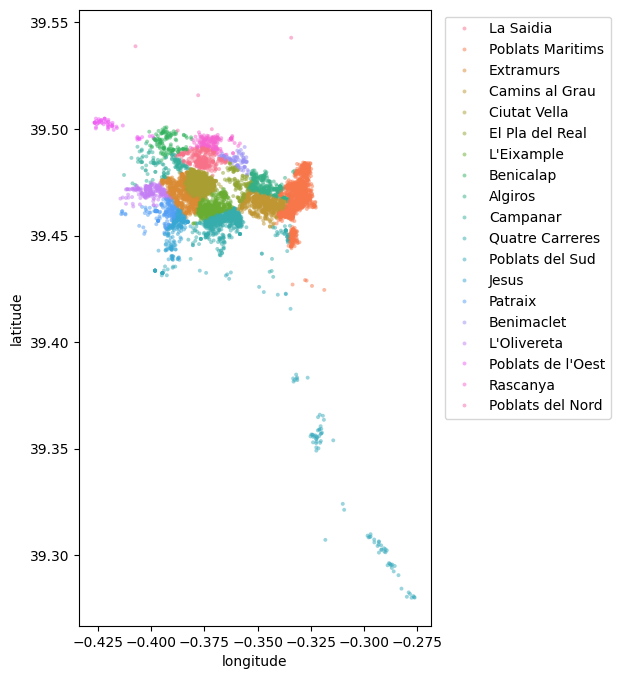

In [63]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_group_cleansed",
    s=8, alpha=0.5, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

Los 19 distritos forman regiones geográficas compactas y reconocibles, lo que confirma que `neighbourhood_group_cleansed` está bien asignado. Al ser más distritos que en Barcelona/Madrid, el mapa queda más fragmentado, pero cada zona sigue siendo consistente.

### 11.3 Precio en el mapa

Text(0, 0.5, 'latitude')

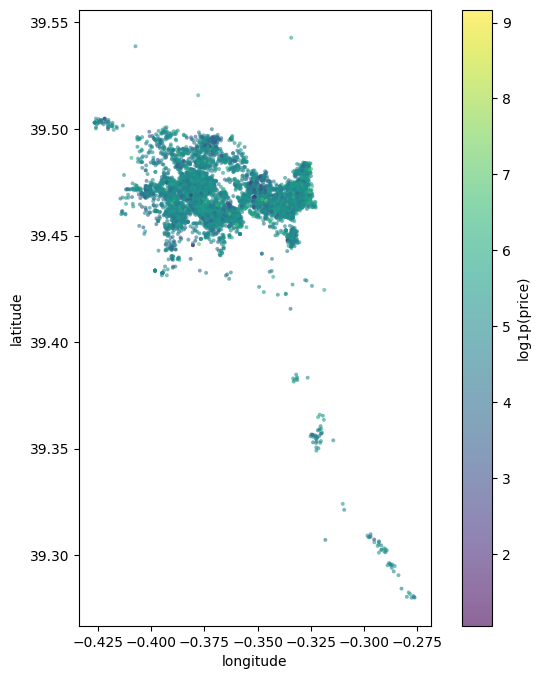

In [64]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

Tonos más claros (precio más alto) hacia el centro histórico y la franja de playa (Poblats Marítims), los dos polos turísticos ya vistos en la sección 9.

### 11.4 Un recordatorio geográfico del artefacto de la sección 8

Antes de corregir los precios de "Camping Valencia" (sección 8.2), el distrito `Poblats del Sud` tenía una media de precio (540€) muy por encima de su propia mediana (143€), un patrón de "media muy por encima de mediana" que suele delatar unos pocos valores extremos. Se comprueba dónde estaban esos 19 bungalows.

In [65]:
import pandas as pd
raw = pd.read_csv(f"{PROJECT_DIR}/data/raw/valencia/listings.csv.gz")
raw["price"] = raw["price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
raw.loc[raw["price"] == 3000.0, "neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
POBLATS DEL SUD    19
Name: count, dtype: int64

Los 19 bungalows de "Camping Valencia" están, sin excepción, en `Poblats del Sud`. Confirma la sospecha: el salto entre media y mediana en ese distrito no era una característica real de la zona, era el artefacto de un solo host concentrado en un único punto del mapa. Buena práctica general: una media muy alejada de la mediana a nivel de grupo es una pista útil para encontrar este tipo de problemas de captura, no solo mirar la distribución global de la variable.

### 11.5 ¿Dónde están los anuncios grandes?

In [66]:
df.loc[df["bedrooms"] >= 6, "neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Ciutat Vella        7
Poblats Maritims    4
Quatre Carreres     3
Extramurs           2
Algiros             2
Camins al Grau      2
El Pla del Real     1
Poblats del Sud     1
Campanar            1
Name: count, dtype: int64

De los 23 anuncios con 6+ dormitorios, 7 están en `Ciutat Vella`, el resto repartidos entre varios distritos. La concentración es mucho más suave que en Barcelona (donde el 75% de los Group Flats estaban en `Eixample`): en Valencia no hay un único distrito que domine claramente los anuncios grandes.

### 11.6 Densidad de anuncios cercanos

`distance_to_center_km` (que se construirá en feature engineering) mide la distancia a un único punto de referencia, pero no captura si un anuncio está en un tramo con mucha oferta de Airbnb alrededor. Se cuenta, para cada anuncio, cuántos otros anuncios reales hay en un radio de 150 metros (con `BallTree` y distancia haversine).

In [67]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
n_nearby_150m = counts - 1  # excluir el propio anuncio

pd.Series(n_nearby_150m, name="n_nearby_150m").describe()

count    7234.000000
mean       38.653027
std        31.315984
min         0.000000
25%        15.000000
50%        30.000000
75%        56.000000
max       163.000000
Name: n_nearby_150m, dtype: float64

Se comprueba la correlación con `price` para valorar si merece la pena como candidata a feature.

In [68]:
pd.Series(n_nearby_150m, index=df.index, name="n_nearby_150m").corr(df["price"])

np.float64(0.10445543615344845)

Correlación positiva y modesta, del mismo orden que en Barcelona: las zonas más densas en anuncios turísticos coinciden con las más céntricas y caras, sin "descuento por competencia" visible a este nivel. Candidata razonable para feature engineering.

## 12. Amenities

En la sección 6.1 `amenities` se clasificó como "cuasi-identificador de texto libre". Antes de decidir qué construir con ella, se cuantifica: qué forma tiene, cuánta variedad real hay, y si alguna señal derivada correlaciona con `price`.

### 12.1 Formato y cardinalidad

In [69]:
import ast
from collections import Counter

amenities_parsed = df["amenities"].apply(ast.literal_eval)
n_amenities = amenities_parsed.apply(len)

print("nulos:", df["amenities"].isna().sum())
n_amenities.describe()

nulos: 0


count    7234.000000
mean       32.009538
std        14.283217
min         0.000000
25%        22.000000
50%        33.000000
75%        42.000000
max        92.000000
Name: amenities, dtype: float64

Sin nulos, media de ~32 amenities por anuncio (mediana 33), de 0 a 92. Se comprueba cuántos valores distintos hay en total.

In [70]:
amenity_counter = Counter()
for lst in amenities_parsed:
    amenity_counter.update(lst)

n_once = sum(1 for c in amenity_counter.values() if c == 1)
print("valores distintos de amenity:", len(amenity_counter))
print(f"aparecen una sola vez: {n_once} de {len(amenity_counter)} ({n_once / len(amenity_counter):.0%})")

valores distintos de amenity: 1820
aparecen una sola vez: 1044 de 1820 (57%)


1820 valores distintos, y más de la mitad (57%) aparece en un único anuncio: la misma cola larguísima ya vista en Barcelona. Un one-hot directo es inviable.

### 12.2 Top amenities y el problema de la fragmentación

In [71]:
pd.Series(dict(amenity_counter.most_common(12)), name="n_anuncios")

Wifi                     6763
Kitchen                  6689
Hot water                6019
Hair dryer               5782
Dishes and silverware    5627
Bed linens               5603
Hangers                  5588
Microwave                5389
Iron                     5367
Cooking basics           5191
Refrigerator             5146
TV                       5010
Name: n_anuncios, dtype: int64

Las más comunes (`Wifi`, `Kitchen`, `Hot water`...) están en 70-95% de los anuncios: casi universales, poco discriminantes. Un mismo concepto también se escribe de varias formas:

In [72]:
ac_variants = [k for k in amenity_counter if "air condition" in k.lower() or k.lower().startswith("ac ")]
{v: amenity_counter[v] for v in sorted(ac_variants, key=lambda k: -amenity_counter[k])}

{'Air conditioning': 4632,
 'AC - split type ductless system': 1061,
 'Central air conditioning': 578,
 'Portable air conditioning': 63}

Cuatro variantes distintas para "tiene aire acondicionado", igual que en Barcelona. Hace falta agrupar por palabra clave, no tomar los valores tal cual.

### 12.3 Candidatas para feature engineering

In [73]:
def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

candidates = pd.DataFrame({
    "n_amenities": n_amenities,
    "has_ac": amenities_parsed.apply(lambda l: has_any(l, ["air condition", "ac - "])),
    "has_pool": amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"])),
    "has_dishwasher": amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"])),
})
candidates["price"] = df["price"]

for col in ["n_amenities", "has_ac", "has_pool", "has_dishwasher"]:
    prevalencia = candidates[col].mean() if col == "n_amenities" else candidates[col].mean() * 100
    corr = candidates[col].astype(float).corr(candidates["price"])
    label = f"media={prevalencia:.1f}" if col == "n_amenities" else f"prevalencia={prevalencia:.1f}%"
    print(f"{col:16s} {label:18s} corr con price: {corr:.3f}")

n_amenities      media=32.0         corr con price: 0.130
has_ac           prevalencia=87.0%  corr con price: 0.153
has_pool         prevalencia=3.0%   corr con price: 0.071
has_dishwasher   prevalencia=37.2%  corr con price: 0.133


`has_pool` destaca aquí con **0.21** de correlación, notablemente más fuerte que en Barcelona (donde apenas llegaba a 0.04): tiene sentido: en una ciudad de playa y clima cálido como Valencia, una piscina privada (presente en solo el 3.2% de los anuncios) es un factor de lujo mucho más diferenciador que en un piso urbano de Barcelona. `has_ac` (0.12) y `has_dishwasher` (0.07) aportan señal más modesta, similar a Barcelona. `n_amenities` en cambio es más débil aquí (0.04). Las cuatro se construyen en `02_feature_engineering.ipynb`, con `has_pool` como candidata especialmente prometedora para Valencia.

## 13. Conclusiones

Resumen de los principales hallazgos del EDA.

### Limpieza aplicada

De las 7851 filas y 90 columnas originales quedan **7234 filas × 78 columnas**:
- 12 columnas 100% vacías eliminadas (las mismas que en Barcelona/Madrid).
- `bathrooms` recuperado desde `bathrooms_text` (1327 de 1334 valores).
- Reviews sin datos por no tener reviews todavía: `reviews_per_month` imputado a 0, el resto se deja como `NaN`/`NaT`.
- `license` convertido en flag `has_license` (80.9% con licencia), y el texto imputado a `"Sin licencia"`.
- Filas sin `price` descartadas (584).
- Columnas de bajo volumen (host/estancia, ~0.18%) descartadas.
- `bedrooms`/`beds` imputados con la mediana por `room_type`.
- `has_availability` eliminada (99.94% constante).
- Sin duplicados de fila completa ni de `id`. 111 "duplicados lógicos" (mismo edificio/residencia) son anuncios reales distintos.
- **20 filas con precios-artefacto descartadas** (9900€ y 3000€, ver sección 8.2): no eran mercado real, eran un patrón conocido de "precio disuasorio" para bloquear fechas de facto.
- 1 fila con `bedrooms`/`beds`/`bathrooms` de captura errónea corregida (sección 8.3).

### Variables nuevas

- `has_license`: flag booleano derivado de `license`.

### El hallazgo principal: el tamaño manda, pero con más ruido que en Barcelona

- `accommodates` (Spearman 0.63), `beds` (0.51) y `bedrooms` (0.39) son las variables más correlacionadas con `price`, el mismo patrón de Barcelona, aunque algo más débil en magnitud.
- Con Pearson las correlaciones son bastante más bajas que con Spearman (`accommodates` 0.35 vs. 0.63): `price` en Valencia tiene una cola larga real más marcada, así que Spearman es la referencia más fiable aquí.
- Relación `bedrooms` → `price` monótona: 1BR ≈ 130€, 2BR ≈ 170€, 3BR ≈ 198€... hasta 6 dormitorios, ≈485€.
- `has_license` importa (158€ vs. 80€ de mediana), aunque el efecto se modera bastante dentro de `Entire home/apt`.
- Igual que en Barcelona, `review_scores_rating` no explica el precio (correlación ~0.03-0.05) y `host_is_superhost` pesa poco.
- Hallazgo propio de Valencia: `has_pool` en amenities correlaciona 0.21 con `price`, mucho más fuerte que en Barcelona: una piscina privada vale más en una ciudad de playa.

### Un artefacto de datos que no estaba en Barcelona/Madrid

- 20 anuncios con precios de 9900€ y 3000€ (0.28% del dataset) resultaron ser un patrón de "precio disuasorio": el host sube el precio a un valor absurdo en vez de bloquear el calendario. Quitar esas 20 filas mejoró la correlación de tamaño con `price` de forma apreciable (`accommodates` de 0.23 a 0.35 en Pearson).
- El distrito `Poblats del Sud` mostraba una media de precio muy alejada de su mediana antes de corregir esto: una señal geográfica útil para detectar este tipo de artefactos en otras ciudades también.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `accommodates`/`bedrooms`/`beds`/`bathrooms` correlacionadas entre sí: vigilar multicolinealidad en un modelo lineal.
- `property_type` (41 categorías) necesitará agrupar las categorías raras.
- Las familias redundantes de `minimum_nights`/`maximum_nights` y `availability` no se han simplificado, solo diagnosticado.
- `price_quote_*` sigue sin decisión. Ya se usó puntualmente en la sección 8 para diagnosticar el artefacto de precio, pero su uso como feature está por evaluar.
- Candidatas a log-transform: `price` (asimetría todavía alta tras la limpieza) y las variables de reviews.
- `has_pool` es una candidata de amenities con más potencial en Valencia que en Barcelona. Priorizarla en feature engineering.

## 14. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/valencia/` para su uso en los siguientes notebooks (feature engineering).

In [74]:
df.to_csv(f"{PROJECT_DIR}/data/processed/valencia/listings_full_clean.csv", index=False)